In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import shutil

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# Create folders
BASE_DIR = "E:/document_forensics/module2_fraud"
folders  = [
    "dataset/authentic",
    "dataset/forged",
    "dataset/train/authentic",
    "dataset/train/forged",
    "dataset/val/authentic",
    "dataset/val/forged",
    "dataset/test/authentic",
    "dataset/test/forged",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("✅ Folder structure created!")

✅ Using device: cuda
✅ GPU: NVIDIA GeForce RTX 4070 Ti SUPER
✅ Folder structure created!


In [2]:
import os, shutil, random
from tqdm import tqdm

RVL_CDIP_ROOT = "E:/RVL-CDIP"
IMAGE_ROOT    = os.path.join(RVL_CDIP_ROOT, "image_jpg")
BASE_DIR      = "E:/document_forensics/module2_fraud"
AUTHENTIC_DIR = f"{BASE_DIR}/dataset/authentic"

# Read train labels
entries = []
with open(os.path.join(RVL_CDIP_ROOT, "labels/train.txt"), "r") as f:
    for line in f:
        line = line.strip()
        if line:
            entries.append(line.split()[0])

print(f"📋 Total available: {len(entries):,}")

# Pick 50,000 images
random.shuffle(entries)
selected = entries[:50000]

copied, failed = 0, 0

for rel_path in tqdm(selected, desc="Copying authentic docs"):
    base = os.path.splitext(rel_path)[0]
    for ext in ['.jpg', '.jpeg', '.tif', '.tiff', '.png']:
        full_path = os.path.join(IMAGE_ROOT, base + ext)
        if os.path.exists(full_path):
            dest = os.path.join(AUTHENTIC_DIR, f"auth_{copied:06d}{ext}")
            shutil.copy2(full_path, dest)
            copied += 1
            break
    else:
        failed += 1

print(f"\n✅ Authentic images copied : {copied:,}")
print(f"⚠️  Failed                  : {failed:,}")

📋 Total available: 320,000


Copying authentic docs: 100%|██████████| 50000/50000 [01:42<00:00, 486.31it/s]


✅ Authentic images copied : 50,000
⚠️  Failed                  : 0


In [3]:
import cv2
import numpy as np
import os
import random
from tqdm import tqdm

AUTHENTIC_DIR = "E:/document_forensics/module2_fraud/dataset/authentic"
FORGED_DIR    = "E:/document_forensics/module2_fraud/dataset/forged"

# ── Fraud Type 1: Copy-Move ──────────────────────────────
def copy_move_forgery(img):
    h, w = img.shape[:2]
    # Pick random region
    x1 = random.randint(0, w//2)
    y1 = random.randint(0, h//2)
    x2 = x1 + random.randint(30, w//3)
    y2 = y1 + random.randint(30, h//3)
    x2, y2 = min(x2, w), min(y2, h)

    # Copy region
    region = img[y1:y2, x1:x2].copy()

    # Paste to different location
    px = random.randint(0, w - (x2-x1))
    py = random.randint(0, h - (y2-y1))
    forged = img.copy()
    forged[py:py+(y2-y1), px:px+(x2-x1)] = region
    return forged

# ── Fraud Type 2: Splicing ───────────────────────────────
def splicing_forgery(img, img2):
    h, w = img.shape[:2]
    h2, w2 = img2.shape[:2]

    # Take region from img2
    x1 = random.randint(0, w2//2)
    y1 = random.randint(0, h2//2)
    rw = random.randint(30, min(w2-x1, w//3))
    rh = random.randint(30, min(h2-y1, h//3))

    region = img2[y1:y1+rh, x1:x1+rw].copy()
    region = cv2.resize(region, (rw, rh))

    # Paste into img
    px = random.randint(0, w - rw)
    py = random.randint(0, h - rh)
    forged = img.copy()
    forged[py:py+rh, px:px+rw] = region
    return forged

# ── Fraud Type 3: Text Tampering ─────────────────────────
def text_tampering(img):
    forged = img.copy()
    h, w   = img.shape[:2]

    # Add white rectangle (simulates erased text)
    x1 = random.randint(0, w//2)
    y1 = random.randint(0, h//2)
    x2 = x1 + random.randint(40, w//3)
    y2 = y1 + random.randint(10, 30)
    x2, y2 = min(x2, w), min(y2, h)
    cv2.rectangle(forged, (x1, y1), (x2, y2), (255, 255, 255), -1)

    # Add fake text (black pixels)
    for _ in range(random.randint(3, 8)):
        tx = random.randint(x1, max(x1+1, x2-20))
        ty = random.randint(y1+5, max(y1+6, y2-2))
        cv2.putText(forged, str(random.randint(0, 9)),
                    (tx, ty), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, (0, 0, 0), 1)
    return forged

# ── Fraud Type 4: Fake Stamp ──────────────────────────────
def fake_stamp(img):
    forged = img.copy()
    h, w   = img.shape[:2]

    # Draw circular stamp
    cx = random.randint(w//4, 3*w//4)
    cy = random.randint(h//4, 3*h//4)
    r  = random.randint(30, 60)

    color = (
        random.randint(0, 100),
        random.randint(0, 100),
        random.randint(150, 255)
    )
    cv2.circle(forged, (cx, cy), r,     color, 2)
    cv2.circle(forged, (cx, cy), r-10,  color, 1)
    cv2.putText(forged, "VERIFIED", (cx-28, cy+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return forged

# ── Generate Forged Dataset ───────────────────────────────
FRAUD_FNS = [
    copy_move_forgery,
    text_tampering,
    fake_stamp
]

images = os.listdir(AUTHENTIC_DIR)
print(f"🔄 Generating forged images for {len(images):,} documents...")
print(f"   Fraud types: Copy-Move, Splicing, Text Tampering, Fake Stamp")

forged_count = 0

for i, fname in enumerate(tqdm(images, desc="Generating forgeries")):
    path = os.path.join(AUTHENTIC_DIR, fname)
    img  = cv2.imread(path)
    if img is None:
        continue

    img = cv2.resize(img, (224, 224))

    # Pick random fraud type
    if len(images) > 1 and random.random() < 0.25:
        # Splicing needs 2 images
        fname2 = random.choice(images)
        img2   = cv2.imread(os.path.join(AUTHENTIC_DIR, fname2))
        if img2 is not None:
            img2   = cv2.resize(img2, (224, 224))
            forged = splicing_forgery(img, img2)
        else:
            forged = random.choice(FRAUD_FNS)(img)
    else:
        forged = random.choice(FRAUD_FNS)(img)

    # Save forged
    forged_name = fname.replace("auth_", "forged_")
    cv2.imwrite(os.path.join(FORGED_DIR, forged_name), forged)

    # Save resized authentic
    cv2.imwrite(os.path.join(AUTHENTIC_DIR, fname), img)
    forged_count += 1

print(f"\n✅ Authentic : {len(os.listdir(AUTHENTIC_DIR)):,}")
print(f"✅ Forged    : {len(os.listdir(FORGED_DIR)):,}")
print(f"🎉 Fraud dataset ready!")

🔄 Generating forged images for 50,000 documents...
   Fraud types: Copy-Move, Splicing, Text Tampering, Fake Stamp


Generating forgeries: 100%|██████████| 50000/50000 [05:10<00:00, 161.00it/s]


✅ Authentic : 50,000
✅ Forged    : 50,000
🎉 Fraud dataset ready!


C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19636\2003138199.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19636\2003138199.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19636\2003138199.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("E:/document_forensics/module2_fraud/results/dataset_samples.png")
C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19636\2003138199.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("E:/document_forensics/module2_fraud/results/dataset_samples.png")
e:\document_forensics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

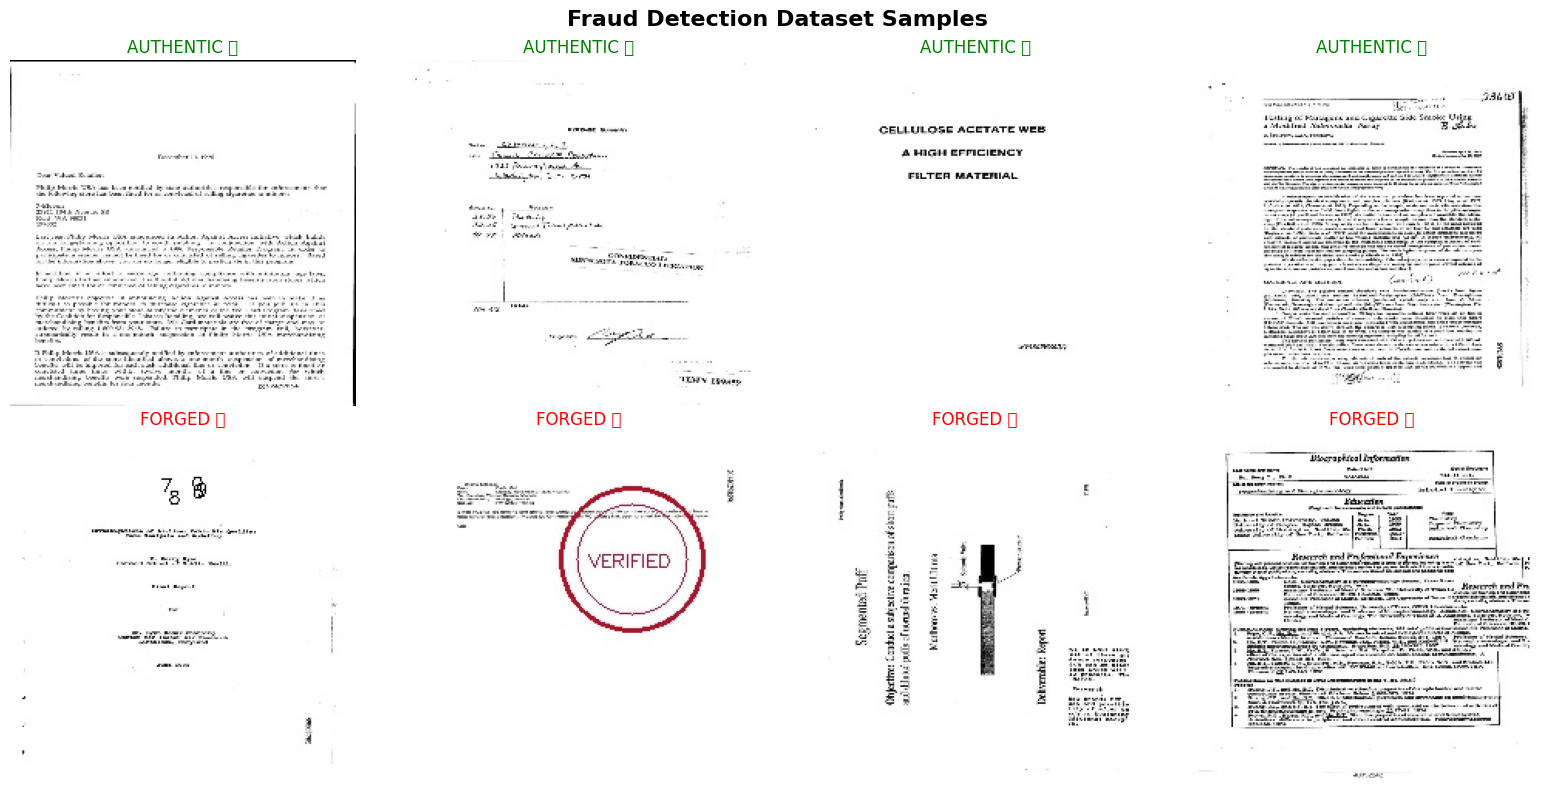

✅ Samples visualized!


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

auth_imgs   = random.sample(os.listdir(AUTHENTIC_DIR), 4)
forged_imgs = random.sample(os.listdir(FORGED_DIR), 4)

for i in range(4):
    a = cv2.imread(os.path.join(AUTHENTIC_DIR, auth_imgs[i]))
    axes[0, i].imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("AUTHENTIC ✅", color="green", fontsize=12)
    axes[0, i].axis("off")

    f = cv2.imread(os.path.join(FORGED_DIR, forged_imgs[i]))
    axes[1, i].imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("FORGED ❌", color="red", fontsize=12)
    axes[1, i].axis("off")

plt.suptitle("Fraud Detection Dataset Samples", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("E:/document_forensics/module2_fraud/results/dataset_samples.png")
plt.show()
print("✅ Samples visualized!")

In [5]:
import os, shutil, random
from tqdm import tqdm

BASE_DIR      = "E:/document_forensics/module2_fraud"
AUTHENTIC_DIR = f"{BASE_DIR}/dataset/authentic"
FORGED_DIR    = f"{BASE_DIR}/dataset/forged"

auth_imgs   = os.listdir(AUTHENTIC_DIR)
forged_imgs = os.listdir(FORGED_DIR)

random.shuffle(auth_imgs)
random.shuffle(forged_imgs)

def split_list(lst):
    n = len(lst)
    return lst[:int(n*0.8)], lst[int(n*0.8):int(n*0.9)], lst[int(n*0.9):]

auth_train,   auth_val,   auth_test   = split_list(auth_imgs)
forged_train, forged_val, forged_test = split_list(forged_imgs)

def copy_files(files, src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for f in tqdm(files, desc=f"→ {os.path.basename(dst_dir)}"):
        shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print("📦 Splitting dataset...")
copy_files(auth_train,   AUTHENTIC_DIR, f"{BASE_DIR}/dataset/train/authentic")
copy_files(auth_val,     AUTHENTIC_DIR, f"{BASE_DIR}/dataset/val/authentic")
copy_files(auth_test,    AUTHENTIC_DIR, f"{BASE_DIR}/dataset/test/authentic")
copy_files(forged_train, FORGED_DIR,    f"{BASE_DIR}/dataset/train/forged")
copy_files(forged_val,   FORGED_DIR,    f"{BASE_DIR}/dataset/val/forged")
copy_files(forged_test,  FORGED_DIR,    f"{BASE_DIR}/dataset/test/forged")

print(f"\n✅ Split complete!")
print(f"   Train → Authentic: {len(auth_train):,} | Forged: {len(forged_train):,}")
print(f"   Val   → Authentic: {len(auth_val):,}   | Forged: {len(forged_val):,}")
print(f"   Test  → Authentic: {len(auth_test):,}  | Forged: {len(forged_test):,}")

📦 Splitting dataset...


→ forged: 100%|██████████| 5000/5000 [00:02<00:00, 1736.33it/s]


✅ Split complete!
   Train → Authentic: 40,000 | Forged: 40,000
   Val   → Authentic: 5,000   | Forged: 5,000
   Test  → Authentic: 5,000  | Forged: 5,000


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, random, torch

class FraudDataset(Dataset):
    def __init__(self, authentic_dir, forged_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        # Authentic = 0, Forged = 1
        for f in os.listdir(authentic_dir):
            self.images.append(os.path.join(authentic_dir, f))
            self.labels.append(0)

        for f in os.listdir(forged_dir):
            self.images.append(os.path.join(forged_dir, f))
            self.labels.append(1)

        combined = list(zip(self.images, self.labels))
        random.shuffle(combined)
        self.images, self.labels = zip(*combined)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.images[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

BASE_DIR = "E:/document_forensics/module2_fraud/dataset"

train_dataset = FraudDataset(f"{BASE_DIR}/train/authentic", f"{BASE_DIR}/train/forged", train_transform)
val_dataset   = FraudDataset(f"{BASE_DIR}/val/authentic",   f"{BASE_DIR}/val/forged",   val_transform)
test_dataset  = FraudDataset(f"{BASE_DIR}/test/authentic",  f"{BASE_DIR}/test/forged",  val_transform)

# num_workers=0 for Windows
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ Train samples : {len(train_dataset):,}")
print(f"✅ Val samples   : {len(val_dataset):,}")
print(f"✅ Test samples  : {len(test_dataset):,}")
print(f"✅ Train batches : {len(train_loader):,}")
print(f"✅ Val batches   : {len(val_loader):,}")
print(f"🚀 DataLoaders ready!")

✅ Train samples : 80,000
✅ Val samples   : 10,000
✅ Test samples  : 10,000
✅ Train batches : 1,250
✅ Val batches   : 157
🚀 DataLoaders ready!


In [7]:
import timm
import torch.nn as nn

class FraudDetector(nn.Module):
    def __init__(self):
        super(FraudDetector, self).__init__()
        self.model = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=2
        )

    def forward(self, x):
        return self.model(x)

# Initialize
model     = FraudDetector().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model      : EfficientNetB3")
print(f"✅ Parameters : {total_params:,}")
print(f"✅ Device     : {device}")
print(f"🚀 Fraud Detector ready!")

✅ Model      : EfficientNetB3
✅ Parameters : 10,699,306
✅ Device     : cuda
🚀 Fraud Detector ready!


In [8]:
EPOCHS    = 15
BEST_ACC  = 0.0
MODEL_DIR = "E:/document_forensics/module2_fraud/models"

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print("🚀 Starting Fraud Detection Training!")
print(f"📊 Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print("=" * 60)

for epoch in range(EPOCHS):
    # ── Training ──
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_total   += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # ── Validation ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  "):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # ── Metrics ──
    t_loss = train_loss / len(train_loader)
    v_loss = val_loss   / len(val_loader)
    t_acc  = 100. * train_correct / train_total
    v_acc  = 100. * val_correct   / val_total

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    scheduler.step()

    # ── Save Best ──
    if v_acc > BEST_ACC:
        BEST_ACC = v_acc
        torch.save(model.state_dict(),
                   f"{MODEL_DIR}/best_fraud_detector.pth")
        saved = "💾 Saved Best!"
    else:
        saved = ""

    print(f"\nEpoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% {saved}")
    print("-" * 60)

print(f"\n🏆 Best Validation Accuracy: {BEST_ACC:.2f}%")
print(f"💾 Saved to: {MODEL_DIR}/best_fraud_detector.pth")

🚀 Starting Fraud Detection Training!
📊 Train: 80,000 | Val: 10,000


Epoch 1/15 [Val]  : 100%|██████████| 157/157 [00:44<00:00,  3.54it/s]



Epoch 01/15 | Train Loss: 0.4330 | Train Acc: 80.36% | Val Loss: 0.2863 | Val Acc: 87.87% 💾 Saved Best!
------------------------------------------------------------


Epoch 2/15 [Val]  : 100%|██████████| 157/157 [00:38<00:00,  4.12it/s]



Epoch 02/15 | Train Loss: 0.3117 | Train Acc: 86.52% | Val Loss: 0.2771 | Val Acc: 88.80% 💾 Saved Best!
------------------------------------------------------------


...


Epoch 13/15 | Train Loss: 0.1075 | Train Acc: 95.90% | Val Loss: 0.2702 | Val Acc: 92.17% 
------------------------------------------------------------


Epoch 14/15 [Val]  : 100%|██████████| 157/157 [00:27<00:00,  5.61it/s]



Epoch 14/15 | Train Loss: 0.0958 | Train Acc: 96.40% | Val Loss: 0.2810 | Val Acc: 91.88% 
------------------------------------------------------------


Epoch 15/15 [Val]  : 100%|██████████| 157/157 [00:29<00:00,  5.34it/s]


Epoch 15/15 | Train Loss: 0.0896 | Train Acc: 96.56% | Val Loss: 0.3022 | Val Acc: 91.96% 
------------------------------------------------------------

🏆 Best Validation Accuracy: 92.55%
💾 Saved to: E:/document_forensics/module2_fraud/models/best_fraud_detector.pth


In [9]:
# Load best model
MODEL_DIR = "E:/document_forensics/module2_fraud/models"
model.load_state_dict(torch.load(f"{MODEL_DIR}/best_fraud_detector.pth"))
model.eval()

test_correct = 0
test_total   = 0

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs      = model(imgs)
        _, predicted = outputs.max(1)
        test_total  += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100. * test_correct / test_total
print(f"\n{'='*40}")
print(f"🏆 FINAL TEST ACCURACY : {test_acc:.2f}%")
print(f"✅ Total test images   : {test_total:,}")
print(f"✅ Correct             : {test_correct:,}")
print(f"❌ Wrong               : {test_total - test_correct:,}")
print(f"{'='*40}")

Testing: 100%|██████████| 157/157 [00:27<00:00,  5.77it/s]


🏆 FINAL TEST ACCURACY : 91.72%
✅ Total test images   : 10,000
✅ Correct             : 9,172
❌ Wrong               : 828
